Part A: Understanding the Dataset 

Q1. Dataset Overview 

Load the dataset and answer the following: 
1. How many rows and columns are present?  

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("agriculture_yield_dataset.csv")
df

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
...,...,...,...,...,...,...,...,...
1495,473.8,32.3,65.0,3.6,5.8,Cotton,Sandy,3.28
1496,825.9,18.4,200.8,9.9,6.7,Cotton,Sandy,5.16
1497,329.3,23.3,90.3,7.7,7.0,Soybean,Sandy,3.60
1498,801.7,28.6,204.1,3.4,6.9,Rice,Sandy,5.03


2. What are the names of all columns?

In [3]:
df.columns

Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='str')

3. Display the first 10 records

In [4]:
df.head(10)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


Q2. Data Types and Missing Values

1. Check the data type of each column.  

In [5]:
df.dtypes

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                    str
soil_type                    str
yield_ton_per_hectare    float64
dtype: object

2. Identify whether any missing values are present.  

In [6]:
df.isnull().sum()

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

3. If missing values exist, mention the affected columns. 

In [7]:
print("Missing values don't exist in the given dataset.")

Missing values don't exist in the given dataset.


Q3. Descriptive Statistics 

Generate summary statistics for all numerical features and answer: 
1. Which feature has the highest mean value?  

In [8]:
df.drop(["crop_type", "soil_type"], axis=1).mean()

rainfall_mm              754.054667
temperature_c             27.749467
fertilizer_kg            148.744067
irrigation_hours           5.403267
soil_ph                    6.759133
yield_ton_per_hectare      5.028793
dtype: float64

2. Which feature has the highest standard deviation? 

In [9]:
df.std(numeric_only = True).idxmax()

'rainfall_mm'

Part B: Exploratory Data Analysis (EDA) 

Q4. Distribution Analysis 

In [10]:
def dataset_analysis(column):
    c = df[column]
    print(f"Skewness: {c.skew()}")
    print(f"Median: {c.median()}")
    print(f"Range: {c.min()}-{c.max()}")
    print(f"Description: {c.describe()}")

Create histograms for:
1. rainfall_mm

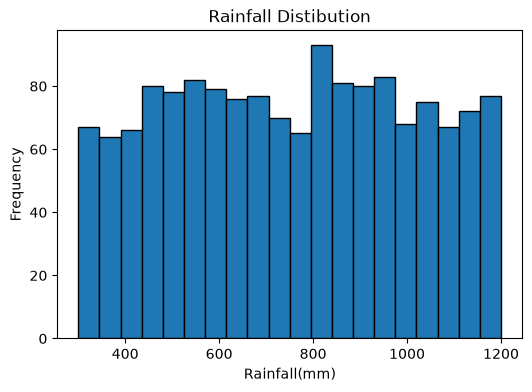

In [11]:
plt.figure(figsize=(6,4))
plt.hist(df['rainfall_mm'], bins = 20, edgecolor = 'black')
plt.title("Rainfall Distibution")
plt.ylabel("Frequency")
plt.xlabel("Rainfall(mm)")
plt.show()

In [12]:
dataset_analysis('rainfall_mm')

Skewness: -0.007099444983961653
Median: 761.2
Range: 300.2-1200.0
Description: count    1500.000000
mean      754.054667
std       255.097216
min       300.200000
25%       536.175000
50%       761.200000
75%       964.375000
max      1200.000000
Name: rainfall_mm, dtype: float64


In [13]:
print("Distribution is roughly symmetric (skew ≈ -0.007) centered ~754 mm")
print("moderate spread (25%–75% ≈ 536–964 mm) with values ranging 300–1200 mm")
print("no strong outliers or heavy skew.")

Distribution is roughly symmetric (skew ≈ -0.007) centered ~754 mm
moderate spread (25%–75% ≈ 536–964 mm) with values ranging 300–1200 mm
no strong outliers or heavy skew.


2. temperature_c

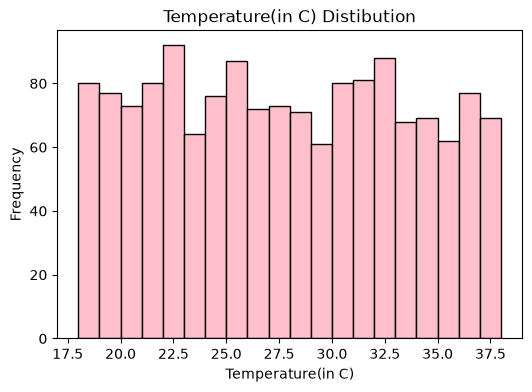

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['temperature_c'], bins = 20, color= "pink", edgecolor = 'black')
plt.title("Temperature(in C) Distibution")
plt.ylabel("Frequency")
plt.xlabel("Temperature(in C)")
plt.show()

In [15]:
dataset_analysis('temperature_c')

Skewness: 0.039574849127497626
Median: 27.7
Range: 18.0-38.0
Description: count    1500.000000
mean       27.749467
std         5.758101
min        18.000000
25%        22.600000
50%        27.700000
75%        32.600000
max        38.000000
Name: temperature_c, dtype: float64


In [16]:
print("Approximately symmetric (skew ≈ 0.04) centered ~27.7°C")
print("most values fall between ~22.6–32.6°C (IQR)\n" \
"range 18–38°C — a modest spread with few extremes.")

Approximately symmetric (skew ≈ 0.04) centered ~27.7°C
most values fall between ~22.6–32.6°C (IQR)
range 18–38°C — a modest spread with few extremes.


3. fertilizer_kg

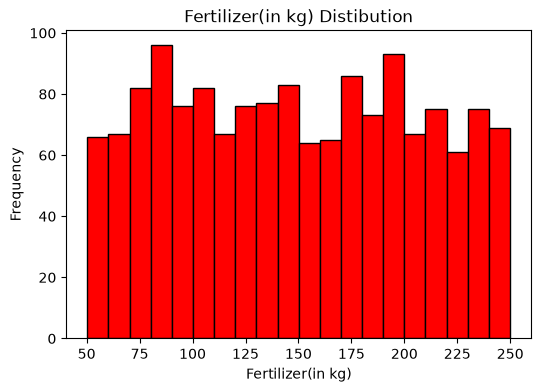

In [17]:
plt.figure(figsize=(6,4))
plt.hist(df['fertilizer_kg'], bins = 20, color= "red", edgecolor = 'black')
plt.title("Fertilizer(in kg) Distibution")
plt.ylabel("Frequency")
plt.xlabel("Fertilizer(in kg)")
plt.show()

In [18]:
dataset_analysis('fertilizer_kg')

Skewness: 0.04059318063342492
Median: 146.85000000000002
Range: 50.3-249.9
Description: count    1500.000000
mean      148.744067
std        56.990279
min        50.300000
25%        98.600000
50%       146.850000
75%       196.575000
max       249.900000
Name: fertilizer_kg, dtype: float64


In [19]:
print("Nearly symmetric (skew ≈ 0.04) around ~149 kg\n" \
"IQR ≈ 98.6–196.6 kg and\n" \
"range ~50–250 kg indicating substantial variability in fertilizer application.")

Nearly symmetric (skew ≈ 0.04) around ~149 kg
IQR ≈ 98.6–196.6 kg and
range ~50–250 kg indicating substantial variability in fertilizer application.


4. yield_ton_per_hectare  

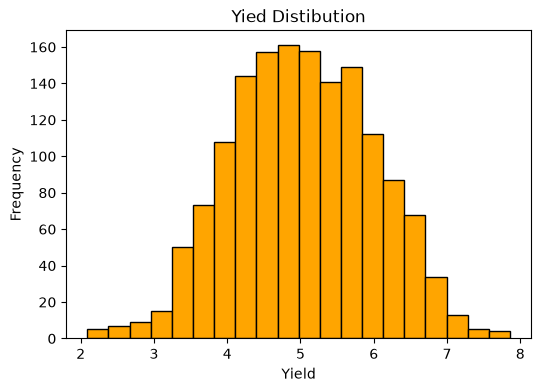

In [20]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins = 20, color= "orange", edgecolor = 'black')
plt.title("Yied Distibution")
plt.ylabel("Frequency")
plt.xlabel("Yield")
plt.show()

In [21]:
dataset_analysis('yield_ton_per_hectare')

Skewness: -0.001169711222739871
Median: 5.01
Range: 2.09-7.86
Description: count    1500.000000
mean        5.028793
std         0.968282
min         2.090000
25%         4.337500
50%         5.010000
75%         5.740000
max         7.860000
Name: yield_ton_per_hectare, dtype: float64


In [22]:
print("Very tightly clustered around ~5.03 t/ha (std ≈ 0.97)\n" \
"IQR ≈ 4.34-5.74 shows most yields near the center,\n" \
"though full range 2.09-7.86 indicates some low/high cases.")

Very tightly clustered around ~5.03 t/ha (std ≈ 0.97)
IQR ≈ 4.34-5.74 shows most yields near the center,
though full range 2.09-7.86 indicates some low/high cases.


Q5. Crop Type Analysis 
1. Find the number of records for each crop type.  

In [23]:
df["crop_type"].value_counts()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

2. Create a count plot (bar chart) for crop_type.  

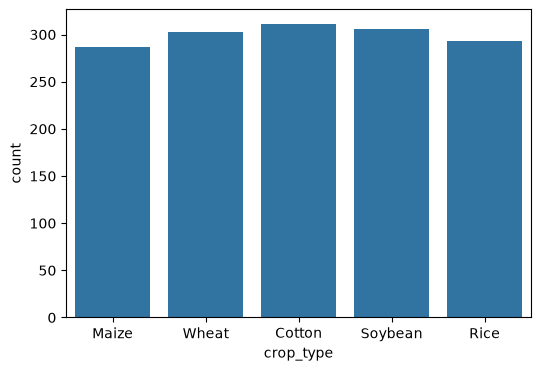

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='crop_type')
plt.show()

3. Which crop appears most frequently? 

In [25]:
print("Cotton appears most frequently as seen in the bar chart.")

Cotton appears most frequently as seen in the bar chart.


Q6. Soil Type Analysis 

1. Find the frequency of each soil type.  

In [26]:
df["soil_type"].value_counts()

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

2. Create a count plot for soil_type.  

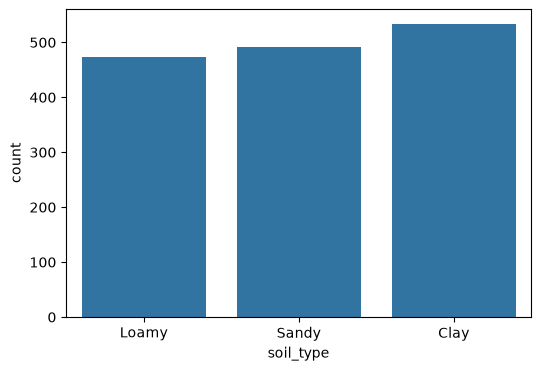

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='soil_type')
plt.show()

3. Which soil type is most common? 

In [28]:
print("Clay soil type is the most common.")

Clay soil type is the most common.


Q7. Yield Distribution 

Create a histogram of yield_ton_per_hectare. 

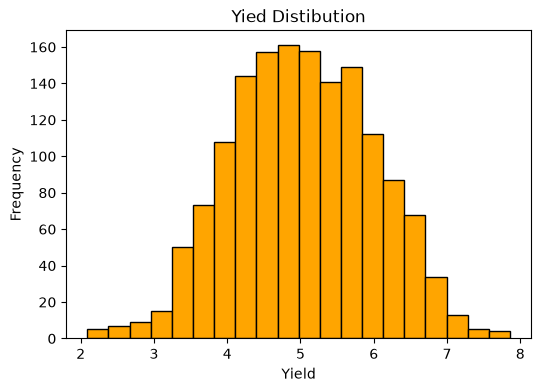

In [29]:
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins = 20, color= "orange", edgecolor = 'black')
plt.title("Yied Distibution")
plt.ylabel("Frequency")
plt.xlabel("Yield")
plt.show()

In [30]:
dataset_analysis('yield_ton_per_hectare')

Skewness: -0.001169711222739871
Median: 5.01
Range: 2.09-7.86
Description: count    1500.000000
mean        5.028793
std         0.968282
min         2.090000
25%         4.337500
50%         5.010000
75%         5.740000
max         7.860000
Name: yield_ton_per_hectare, dtype: float64


1. Is the distribution approximately normal?  

In [31]:
print("Yes, the distribution is very close to normal.")

Yes, the distribution is very close to normal.


2. Are there any noticeable outliers? 

In [32]:
print("Very few.\n" \
"Only a handful of values fall outside the upper and loweer thresholds — the distribution has minimal outliers")

Very few.
Only a handful of values fall outside the upper and loweer thresholds — the distribution has minimal outliers


Q8. Scatter Plot Analysis 

Create scatter plots of: 

1. rainfall_mm vs yield_ton_per_hectare  

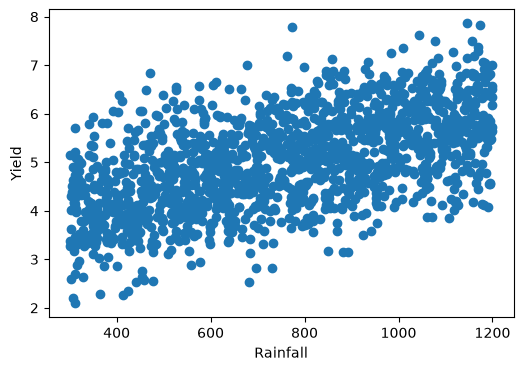

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(
    df['rainfall_mm'],
    df['yield_ton_per_hectare']
)
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

2. fertilizer_kg vs yield_ton_per_hectare  

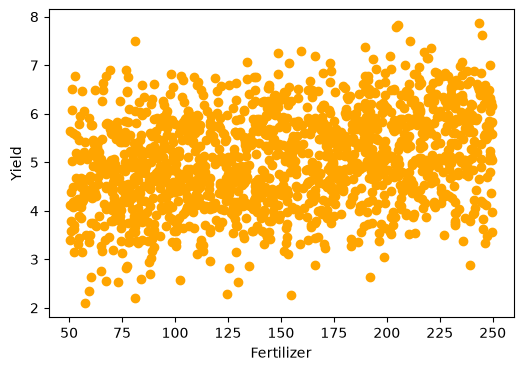

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(
    df['fertilizer_kg'],
    df['yield_ton_per_hectare'],
    color= "orange"
)
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

In [35]:
print("rainfall_mm appears to have the stronger relationship with yield_ton_per_hectare.\n" \
"The plot with fertilizer_kg shows a weaker positive relationship while with rainfall_mm shows moderate positive reltionship.")

rainfall_mm appears to have the stronger relationship with yield_ton_per_hectare.
The plot with fertilizer_kg shows a weaker positive relationship while with rainfall_mm shows moderate positive reltionship.


Q9. Correlation Analysis 

1. Generate a correlation matrix for numerical features.  

In [36]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

In [37]:
print("Understanding Correlation Values\n"
"\n"
"No Correlation: A correlation value of 0 means no linear relationship between the variables. As one changes, the other does not follow any predictable pattern.\n" \
"Positive Correlation: A value closer to +1 indicates a direct relationship as one variable increases, the other also increases. Example: height and weight.\n" \
"Negative Correlation: A value closer to -1 indicates an inverse relationship as one variable increases, the other decreases. Example: speed and travel time.\n")

Understanding Correlation Values

No Correlation: A correlation value of 0 means no linear relationship between the variables. As one changes, the other does not follow any predictable pattern.
Positive Correlation: A value closer to +1 indicates a direct relationship as one variable increases, the other also increases. Example: height and weight.
Negative Correlation: A value closer to -1 indicates an inverse relationship as one variable increases, the other decreases. Example: speed and travel time.



2. Create a heatmap.  

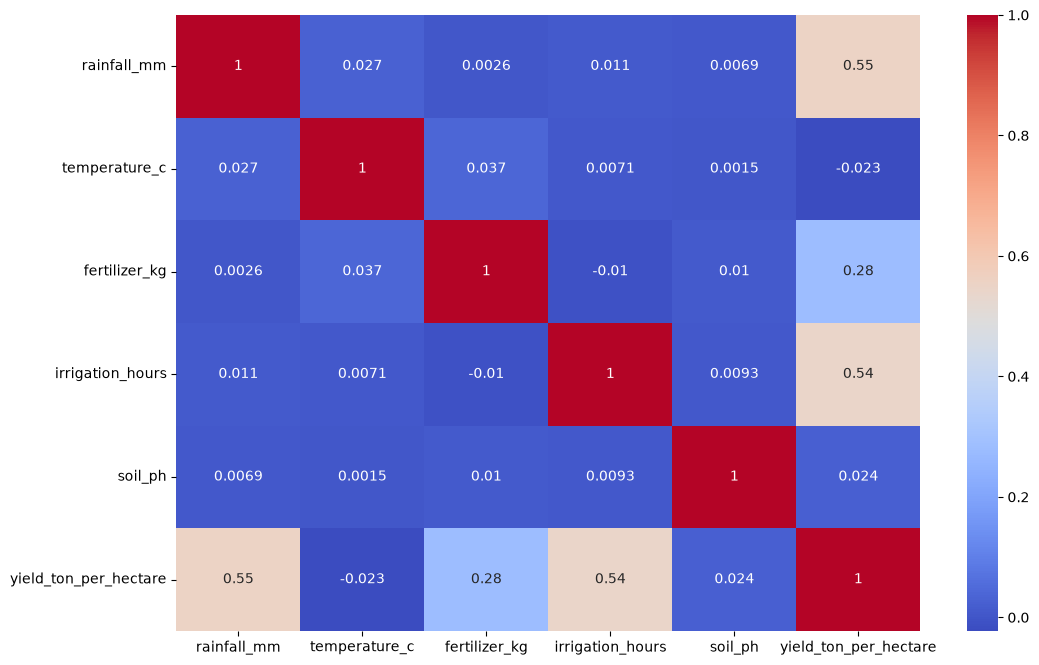

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.show()

3. Identify the top three features most correlated with crop yield. 

In [39]:
corr_with_yield = corr_matrix['yield_ton_per_hectare']

top_features = corr_with_yield.abs().sort_values(
    ascending=False
)

print(top_features)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c            0.022559
Name: yield_ton_per_hectare, dtype: float64


Q10. Group-Based Analysis 

Calculate the average yield for: 

1. Each crop type  

In [40]:
df

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
...,...,...,...,...,...,...,...,...
1495,473.8,32.3,65.0,3.6,5.8,Cotton,Sandy,3.28
1496,825.9,18.4,200.8,9.9,6.7,Cotton,Sandy,5.16
1497,329.3,23.3,90.3,7.7,7.0,Soybean,Sandy,3.60
1498,801.7,28.6,204.1,3.4,6.9,Rice,Sandy,5.03


In [41]:
df['crop_type'].value_counts()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64

In [43]:
crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
crop_avg

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

2. Each soil type  

In [45]:
soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
soil_avg

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Which crop and soil type have the highest average yield? 

In [48]:
print(f"{crop_avg.idxmax()} crop type has the highest average yield.")
print(f"{soil_avg.idxmax()} soil type has the highest average yield.")

Rice crop type has the highest average yield.
Loamy soil type has the highest average yield.


Part C: Data Preparation 

Q11. Feature Encoding 

The dataset contains categorical variables. 

1. Identify the categorical columns.  

In [53]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['crop_type', 'soil_type'], dtype='str')


C:\Users\Deeksha\AppData\Local\Temp\ipykernel_4868\4182786301.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


2. Convert them into numerical form using One-Hot Encoding.  

In [58]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

3. Display the first five rows of the transformed dataset. 

In [59]:
df_encoded.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


Q12. Feature Selection 

Separate: 

1. Input features (X)  

In [60]:
X = df_encoded.drop('yield_ton_per_hectare', axis =1)

2. Target variable (y)  

In [63]:
y = df_encoded['yield_ton_per_hectare']

Specify which column is being used as the target variable. 

In [61]:
print("Yield column is being used as the target variable.")

Yield column is being used as the target variable.


In [67]:
print('Input features (X)')
print(X.head())

Input features (X)
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Maize  crop_type_Rice  crop_type_Soybean  crop_type_Wheat  \
0             True           False              False            False   
1             True           False              False            False   
2            False           False              False             True   
3             True           False              False            False   
4            False           False              False            False   

   soil_type_Loamy  soil_type_Sandy  
0             True            False  
1        

In [68]:
print('Target variable (y)')
print(y.head())

Target variable (y)
0    5.92
1    6.24
2    4.77
3    4.04
4    5.17
Name: yield_ton_per_hectare, dtype: float64


Part D: Machine Learning 

Q13. Train-Test Split 

Split the dataset into: 

1. 80% Training Data  
2. 20% Testing Data

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the shape of: 
1. X_train
2. X_test  
3. y_train  
4. y_test  

In [73]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1200, 11)
Shape of X_test: (300, 11)
Shape of y_train: (1200,)
Shape of y_test: (300,)


Q14. Linear Regression Model 

1. Train a Linear Regression model.  

In [74]:
from sklearn.linear_model import LinearRegression

In [75]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0. ,-0.01, 0. ,..., 0.35, 0.3 ,-0.49]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['rainfall_mm','temperature_c','fertilizer_kg',...,'crop_type_Wheat', 'soil_type_Loamy','soil_type_Sandy']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.587
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


2. Display the model coefficients and intercept.  

In [77]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
coefficients

,Feature,Coefficient
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
2,fertilizer_kg,0.004978
3,irrigation_hours,0.198327
4,soil_ph,0.004901
5,crop_type_Maize,0.238931
6,crop_type_Rice,0.863993
7,crop_type_Soybean,0.481719
8,crop_type_Wheat,0.348474
9,soil_type_Loamy,0.302974


In [79]:
print("Intercept:")
lr_model.intercept_

Intercept:


np.float64(1.587132027736125)

3. Which feature has the highest positive coefficient? 

In [80]:
highest_feature = coefficients.loc[coefficients['Coefficient'].idxmax()]
highest_feature

Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object